# Notebook 74: Two-Population Toy Model for the Primary-Mass Distribution

In [31]:
nb_id = 74

Can a *shallow* second population hide inside an otherwise power-law
$\mathrm{d}R/\mathrm{d}m_1$, showing up only as a change of slope rather than as an
obvious peak?

The toy model here superposes

1. a **power law** with a lower break at $10\,\mathrm{M}_\odot$, and
2. a **shallow Gaussian** spanning roughly $20$–$50\,\mathrm{M}_\odot$,

and asks how much of the rate the Gaussian may carry before the total stops being
monotonic. Everything is customisable through a single dataclass; no MESA data or
fitting is involved.

#### Setup

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import simpson
from scipy.special import log_ndtr
from functools import lru_cache
from dataclasses import dataclass, replace
from typing import Optional

import sys
sys.path.append('..')
from src.util import (savefig_base, NB_OUTPUT_DIR)

plt.style.use('plotstyle.mplstyle')

In [33]:
FIGURE_FOLDER = NB_OUTPUT_DIR / f'nb{nb_id:02d}/plots'
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)
def savefig(*args, **kwargs): 
    savefig_base(*args, nb_id=nb_id, figure_folder=FIGURE_FOLDER, **kwargs)

In [34]:
# component colours used throughout
C_PL  = '#4C72B0'   # power-law population
C_G   = '#C44E52'   # Gaussian population
C_TOT = 'k'         # total

## 1. Model definition

Both components are normalised to unit integral over $[m_\mathrm{min}, m_\mathrm{max}]$
and mixed with a single branching fraction $f$:

$$\frac{\mathrm{d}R}{\mathrm{d}m_1} = R_\mathrm{tot}\,\Big[(1-f)\,p_\mathrm{pl}(m) + f\,p_\mathrm{g}(m)\Big].$$

Normalising *before* mixing means $f$ is exactly the fraction of mergers belonging to
the Gaussian population, which decouples "how much" from "what shape".

**Power law.** A single slope $\alpha$ with a smoothed low-mass turn-on (the LVK
`POWER LAW + PEAK` convention),

$$p_\mathrm{pl}(m)\ \propto\ m^{-\alpha}\,S(m\,|\,m_\mathrm{min},\delta_m),\qquad
S = \begin{cases}
0 & m < m_\mathrm{min}\\[2pt]
\left[\exp\!\left(\frac{\delta_m}{m'} + \frac{\delta_m}{m'-\delta_m}\right)+1\right]^{-1}
  & m_\mathrm{min}\le m < m_\mathrm{min}+\delta_m\\[2pt]
1 & m \ge m_\mathrm{min}+\delta_m
\end{cases}$$

with $m' = m - m_\mathrm{min}$. Setting `alpha_low` instead gives a genuine broken power
law (slope $\alpha_\mathrm{low}$ below `m_break`, $\alpha$ above, continuous at the break).
The smoothed turn-on is the better default here: a real break at $10\,\mathrm{M}_\odot$
introduces a *second* slope change that competes with the one we are trying to attribute
to the Gaussian.

**Skewed second population.** A skew normal in $m$ — steep rise on the low-mass side,
long tail to high mass:

$$p_\mathrm{g}(m)\ \propto\ \exp\!\left(-\tfrac{1}{2}z^{2}\right)\,\Phi(a\,z),
\qquad z = \frac{m-\xi}{\omega},$$

with $\Phi$ the standard normal CDF, $\omega$ the scale and $a$ the shape. $a>0$ gives the
asymmetry we want and $a=0$ recovers an ordinary Gaussian. The two flanks have very
different widths: the low-mass side falls off with effective width $\omega/\sqrt{1+a^{2}}$
while the high-mass tail keeps the full $\omega$, so $a=6$ makes the rise
$\sqrt{37}\approx 6\times$ steeper than the tail.

**The location $\xi$ is not the peak.** Sweeps are only interpretable if the bump stays
put, so the model takes `mu` as the **mode** and solves $\xi = \mu - \omega\,z_0(a)$, where
$z_0(a)$ is the mode of the standard skew normal — no closed form, found numerically and
cached on $a$. Defaults $\mu = 35$, $\omega = 15$, $a = 6$ put the peak at
$35\,\mathrm{M}_\odot$ with a 5–95% span of roughly $30$–$59\,\mathrm{M}_\odot$.

Skewed in $m$, not in $\log m$: the slope diagnostic below is defined against $m$.

In [35]:
def smoothing(m, m_min, delta_m):
    """LVK-style low-mass turn-on: 0 below m_min, rising to 1 at m_min + delta_m."""
    m = np.atleast_1d(np.asarray(m, dtype=float))
    s = np.zeros_like(m)
    if delta_m <= 0:
        s[m >= m_min] = 1.0
        return s
    s[m >= m_min + delta_m] = 1.0
    w = (m > m_min) & (m < m_min + delta_m)
    mp = m[w] - m_min
    s[w] = 1.0 / (np.exp(delta_m / mp + delta_m / (mp - delta_m)) + 1.0)
    return s


def powerlaw_shape(m, alpha, m_min, m_max, delta_m, alpha_low=None, m_break=10.0):
    """Unnormalised power-law component, zero outside [m_min, m_max].

    alpha_low is None -> single slope -alpha; the low-mass end is set by the smoothed
                         turn-on at m_min (this is the 'break at 10 Msun' by default).
    alpha_low given   -> broken power law, slope -alpha_low below m_break and -alpha
                         above, continuous at m_break.
    """
    m = np.atleast_1d(np.asarray(m, dtype=float))
    shape = np.zeros_like(m)
    ok = m > 0
    shape[ok] = m[ok] ** (-alpha)
    if alpha_low is not None:
        lo = ok & (m < m_break)
        shape[lo] = m_break ** (-alpha) * (m[lo] / m_break) ** (-alpha_low)
    shape *= smoothing(m, m_min, delta_m)
    shape[(m < m_min) | (m > m_max)] = 0.0
    return shape


def skewnormal_shape(m, xi, omega, skew, m_min, m_max):
    """Unnormalised skew normal in m, truncated to [m_min, m_max].

    skew > 0 -> steep rise from low mass, long tail to high mass. skew = 0 -> Gaussian.
    Built in logs (log_ndtr) so the deep low-mass flank underflows to 0 instead of NaN.
    """
    m = np.atleast_1d(np.asarray(m, dtype=float))
    z = (m - xi) / omega
    shape = np.exp(-0.5 * z ** 2 + log_ndtr(skew * z))
    shape[(m < m_min) | (m > m_max)] = 0.0
    return shape


def dln_skewnormal_dm(m, xi, omega, skew):
    """d ln p / dm of the (untruncated) skew normal.

    Positive below the mode, negative above. The inverse Mills ratio phi(az)/Phi(az) is
    evaluated in logs so it stays finite far out on the suppressed flank.
    """
    m = np.atleast_1d(np.asarray(m, dtype=float))
    z = (m - xi) / omega
    a = skew * z
    mills = np.exp(-0.5 * a ** 2 - 0.5 * np.log(2.0 * np.pi) - log_ndtr(a))
    return (-z + skew * mills) / omega


@lru_cache(maxsize=None)
def standard_skewnormal_mode(skew, n=40001):
    """Mode z_0 of the standard (xi=0, omega=1) skew normal. Cached: depends only on skew."""
    z = np.linspace(-8.0, 8.0 + 4.0 * abs(skew), n)
    return float(z[np.argmax(-0.5 * z ** 2 + log_ndtr(skew * z))])

In [36]:
@dataclass
class ToyMassModel:
    """Power law + skewed second population, as a toy dR/dm1.

    dR/dm = R_tot * [ (1 - f) * p_pl(m) + f * p_g(m) ],  both components unit-normalised
    over [m_min, m_max], so f is the fraction of mergers in the second population.
    """
    # --- power-law population --------------------------------------------
    alpha: float = 3.5              # dN/dm ~ m^-alpha
    m_min: float = 10.0             # lower break / turn-on
    m_max: float = 100.0
    delta_m: float = 4.0            # width of the smoothed turn-on
    alpha_low: Optional[float] = None   # set for a genuine broken power law
    m_break: float = 10.0
    # --- skewed population -------------------------------------------------
    mu: float = 35.0                # MODE of the bump, not the location parameter
    omega: float = 15.0             # scale
    skew: float = 6.0               # shape a; 0 -> Gaussian, >0 -> tail to high mass
    # --- mixture -----------------------------------------------------------
    f: float = 0.07                 # fraction of mergers in the skewed population
    R_tot: float = 20.0             # Gpc^-3 yr^-1
    # --- numerics ----------------------------------------------------------
    n_grid: int = 4000

    @property
    def grid(self):
        """Dense grid used for normalisation and monotonicity tests."""
        return np.linspace(self.m_min, self.m_max, self.n_grid)

    @property
    def xi(self):
        """Location parameter placing the mode of the skewed component at mu."""
        return self.mu - self.omega * standard_skewnormal_mode(self.skew)

    def pdf_pl(self, m):
        g = self.grid
        kw = dict(alpha=self.alpha, m_min=self.m_min, m_max=self.m_max,
                  delta_m=self.delta_m, alpha_low=self.alpha_low, m_break=self.m_break)
        return powerlaw_shape(m, **kw) / simpson(powerlaw_shape(g, **kw), x=g)

    def pdf_g(self, m):
        g = self.grid
        kw = dict(xi=self.xi, omega=self.omega, skew=self.skew,
                  m_min=self.m_min, m_max=self.m_max)
        return skewnormal_shape(m, **kw) / simpson(skewnormal_shape(g, **kw), x=g)

    def dln_pdf_g_dm(self, m):
        """d ln p_g / dm, needed for the slope identity and the kink/peak criterion."""
        return dln_skewnormal_dm(m, self.xi, self.omega, self.skew)

    def components(self, m):
        """(power-law part, skewed part) of dR/dm."""
        return (self.R_tot * (1.0 - self.f) * self.pdf_pl(m),
                self.R_tot * self.f * self.pdf_g(m))

    def dRdm(self, m):
        pl, gs = self.components(m)
        return pl + gs

    def bump_fraction(self, m):
        """g(m): local fraction of the rate supplied by the skewed population."""
        pl, gs = self.components(m)
        tot = pl + gs
        return np.where(tot > 0, gs / np.where(tot > 0, tot, 1.0), np.nan)

    def log_slope(self, m):
        """Gamma = dln(dR/dm)/dln m by finite differences on the supplied grid."""
        m = np.atleast_1d(np.asarray(m, dtype=float))
        y = self.dRdm(m)
        out = np.full_like(y, np.nan)
        ok = y > 0
        out[ok] = np.gradient(np.log(y[ok]), np.log(m[ok]))
        return out

    def log_slope_analytic(self, m):
        """Gamma from the mixture identity (exact where the turn-on is saturated)."""
        m = np.atleast_1d(np.asarray(m, dtype=float))
        g = self.bump_fraction(m)
        return -self.alpha * (1.0 - g) + g * m * self.dln_pdf_g_dm(m)

    def is_monotonic(self, m=None):
        """True if dR/dm decreases monotonically above the turn-on: a kink, not a peak."""
        m = self.grid if m is None else np.atleast_1d(np.asarray(m, dtype=float))
        interior = m >= self.m_min + self.delta_m
        return not np.any(np.diff(self.dRdm(m)[interior]) > 0.0)

## 2. The fiducial model

Defaults: $\alpha = 3.5$, break at $10\,\mathrm{M}_\odot$ smoothed over
$\delta_m = 4\,\mathrm{M}_\odot$; skewed bump peaking at $\mu = 35$ with scale
$\omega = 15$ and shape $a = 6$, carrying $f = 7\%$ of the mergers.

$f = 7\%$ is chosen to sit just below the kink/peak threshold of Section 6
($f_\mathrm{crit} \simeq 0.098$ for these settings): enough to bend the slope from
$-3.5$ to $\simeq -2.0$ at the mode, not enough to turn the total over. Note how much
less budget the skew leaves than a symmetric bump would — at $a=0$ the same
$\omega$ tolerates $f_\mathrm{crit} \simeq 0.62$.

In [37]:
model = ToyMassModel()
m = np.linspace(model.m_min + model.delta_m, model.m_max, 1500)

pl, gs = model.components(m)
tot = pl + gs
i_mu = np.argmin(abs(m - model.mu))

print(f'f                        = {model.f:.3f}')
print(f'xi (location)            = {model.xi:.2f} Msun')
print(f'mode of bump             = {m[np.argmax(gs)]:.1f} Msun')
print(f'rise width  omega/sqrt(1+a^2) = {model.omega / np.sqrt(1 + model.skew**2):.2f} Msun')
print(f'tail width  omega        = {model.omega:.2f} Msun')
print(f'g(mu)  local bump share  = {model.bump_fraction(m)[i_mu]:.3f}')
print(f'Gamma at mu              = {model.log_slope(m)[i_mu]:+.2f}')
print(f'Gamma of pure power law  = {-model.alpha:+.2f}')
print(f'monotonic (kink only)?   = {model.is_monotonic()}')

f                        = 0.070
xi (location)            = 30.00 Msun
mode of bump             = 35.0 Msun
rise width  omega/sqrt(1+a^2) = 2.47 Msun
tail width  omega        = 15.00 Msun
g(mu)  local bump share  = 0.431
Gamma at mu              = -1.99
Gamma of pure power law  = -3.50
monotonic (kink only)?   = True


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


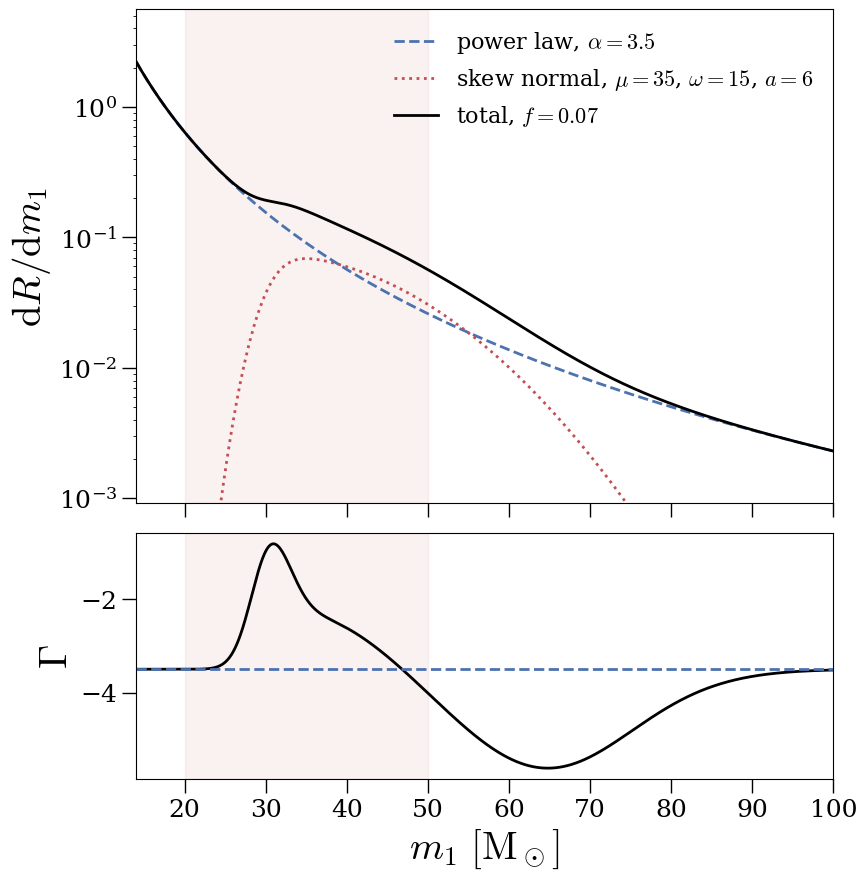

In [38]:
fig, (ax, axs) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                              gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for a in (ax, axs):
    a.axvspan(20, 50, color=C_G, alpha=0.08, zorder=0)

ax.semilogy(m, pl, ls='--', color=C_PL,
            label=rf'power law, $\alpha={model.alpha:.1f}$')
ax.semilogy(m, gs, ls=':', color=C_G,
            label=rf'skew normal, $\mu={model.mu:.0f}$, $\omega={model.omega:.0f}$, $a={model.skew:.0f}$')
ax.semilogy(m, tot, color=C_TOT, label=rf'total, $f={model.f:.2f}$')
ax.set_ylim(tot.min() * 0.4, tot.max() * 2.5)
ax.set_ylabel(r'$\mathrm{d}R/\mathrm{d}m_1$')
ax.legend(frameon=False, fontsize=16)

axs.plot(m, model.log_slope(m), color=C_TOT)
axs.axhline(-model.alpha, ls='--', color=C_PL)
axs.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
axs.set_ylabel(r'$\Gamma$')
axs.set_xlim(m.min(), m.max())

savefig(fig, 'fiducial_rate_and_slope')

On the rate panel the Gaussian is barely visible; on the slope panel it is
unmistakable. **Plot $\Gamma$, not just $\mathrm{d}R/\mathrm{d}m$** — that is the whole
point of the diagnostic below.

## 3. The local log-slope identity

Define the local logarithmic slope

$$\Gamma(m) \equiv \frac{\mathrm{d}\ln (\mathrm{d}R/\mathrm{d}m)}{\mathrm{d}\ln m},$$

which is $-\alpha$, flat, for a pure power law. Writing $g(m)$ for the *local* fraction of
the rate supplied by the second population,

$$g(m) = \frac{f\,p_\mathrm{g}}{(1-f)\,p_\mathrm{pl} + f\,p_\mathrm{g}},$$

differentiating the mixture gives the whole story in one line, for **any** bump shape:

$$\boxed{\ \Gamma(m) = -\alpha\,\big[1 - g(m)\big] \;+\; g(m)\;m\,\frac{\mathrm{d}\ln p_\mathrm{g}}{\mathrm{d}m}\ }$$

Only the last factor knows about the shape. For a symmetric Gaussian
$\mathrm{d}\ln p_\mathrm{g}/\mathrm{d}m = -(m-\mu)/\sigma^{2}$ and the identity reduces to
the familiar $-\alpha(1-g) - g\,m(m-\mu)/\sigma^{2}$. For the skew normal,

$$\frac{\mathrm{d}\ln p_\mathrm{g}}{\mathrm{d}m}
= \frac{1}{\omega}\left[-z + a\,\frac{\phi(az)}{\Phi(az)}\right],
\qquad z=\frac{m-\xi}{\omega},$$

with $\phi/\Phi$ the inverse Mills ratio. The asymmetry shows up directly: the term is
large and positive on the steep low-mass flank and only weakly negative along the tail, so
a skewed bump **flattens the slope over a wide range of $m$ and steepens it sharply over a
narrow one** — the opposite of the symmetric case.

The identity is exact wherever the turn-on window is saturated, $m > m_\mathrm{min}+\delta_m$.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


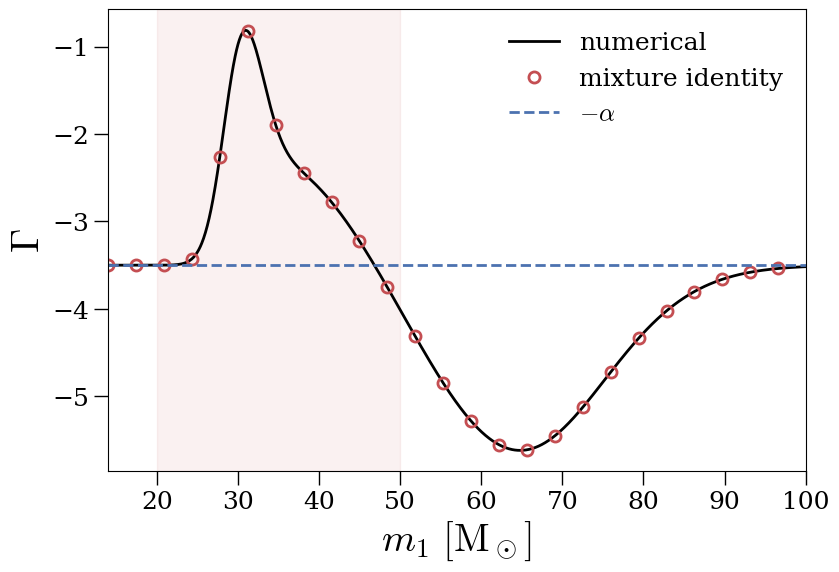

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.axvspan(20, 50, color=C_G, alpha=0.08, zorder=0)
ax.plot(m, model.log_slope(m), color=C_TOT, label='numerical')
ax.plot(m[::60], model.log_slope_analytic(m)[::60], 'o', ms=8, mfc='none',
            mew=2, color=C_G, label='mixture identity')
ax.axhline(-model.alpha, ls='--', color=C_PL, label=r'$-\alpha$')
ax.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
ax.set_ylabel(r'$\Gamma$')
ax.set_xlim(m.min(), m.max())
ax.legend(frameon=False, fontsize=18)

savefig(fig, 'log_slope_identity_check')

## 4. Varying the branching fraction $f$

$f$ controls *how much* slope change there is, at fixed shape.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


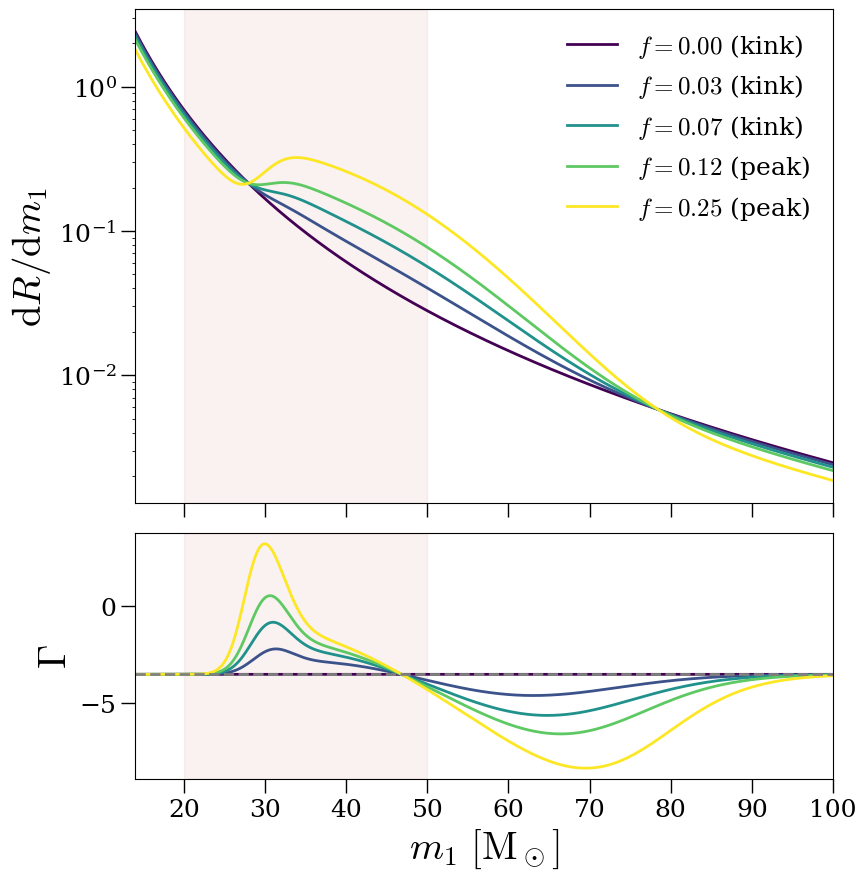

In [40]:
f_values = [0.0, 0.03, 0.07, 0.12, 0.25]
cmap = plt.get_cmap('viridis')
colors = [cmap(i / max(len(f_values) - 1, 1)) for i in range(len(f_values))]

fig, (ax, axs) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                              gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))
for a in (ax, axs):
    a.axvspan(20, 50, color=C_G, alpha=0.08, zorder=0)

for f_val, c in zip(f_values, colors):
    mdl = replace(model, f=f_val)
    mono = 'kink' if mdl.is_monotonic() else 'peak'
    ax.semilogy(m, mdl.dRdm(m), color=c, label=rf'$f={f_val:.2f}$ ({mono})')
    axs.plot(m, mdl.log_slope(m), color=c)

axs.axhline(-model.alpha, ls='--', color='0.5')
ax.set_ylabel(r'$\mathrm{d}R/\mathrm{d}m_1$')
ax.legend(frameon=False, fontsize=18)
axs.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
axs.set_ylabel(r'$\Gamma$')
axs.set_xlim(m.min(), m.max())

savefig(fig, 'vary_branching_fraction')

## 5. Varying the scale $\omega$

$\omega$ sets how far the tail reaches. At fixed $f$ a small $\omega$ concentrates the same
number of mergers into a narrower range, raising the local share $g$ near the mode.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


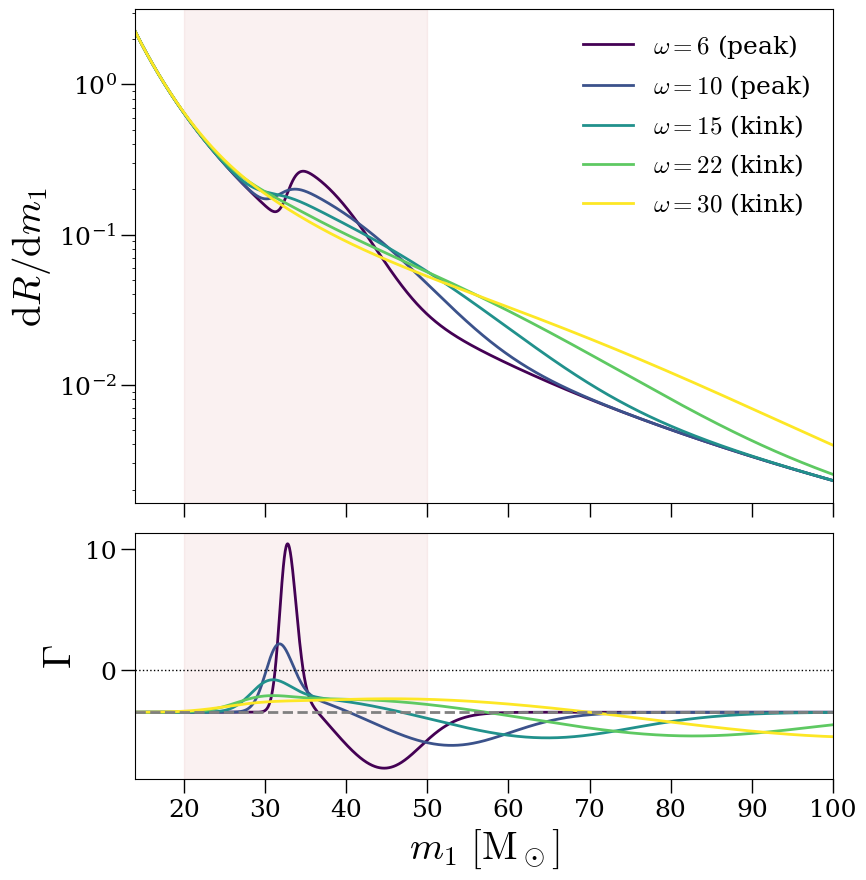

In [41]:
omega_values = [6.0, 10.0, 15.0, 22.0, 30.0]
colors = [cmap(i / max(len(omega_values) - 1, 1)) for i in range(len(omega_values))]

fig, (ax, axs) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                              gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))
for a in (ax, axs):
    a.axvspan(20, 50, color=C_G, alpha=0.08, zorder=0)

for w_val, c in zip(omega_values, colors):
    mdl = replace(model, omega=w_val)
    mono = 'kink' if mdl.is_monotonic() else 'peak'
    ax.semilogy(m, mdl.dRdm(m), color=c, label=rf'$\omega={w_val:.0f}$ ({mono})')
    axs.plot(m, mdl.log_slope(m), color=c)

axs.axhline(-model.alpha, ls='--', color='0.5')
axs.axhline(0.0, ls=':', color='k', lw=1)
ax.set_ylabel(r'$\mathrm{d}R/\mathrm{d}m_1$')
ax.legend(frameon=False, fontsize=18)
axs.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
axs.set_ylabel(r'$\Gamma$')
axs.set_xlim(m.min(), m.max())

savefig(fig, 'vary_scale')

## 5b. Varying the skew $a$

At fixed mode and scale, $a$ trades a symmetric bump ($a=0$) for an increasingly
lopsided one. Because the mode is pinned at $\mu$, what changes is purely the
*asymmetry*: the low-mass flank steepens as $\omega/\sqrt{1+a^{2}}$ while the tail keeps
its width. Watch $\Gamma$ — the flattened region spreads to high mass and the steepening
piles up just below the mode.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


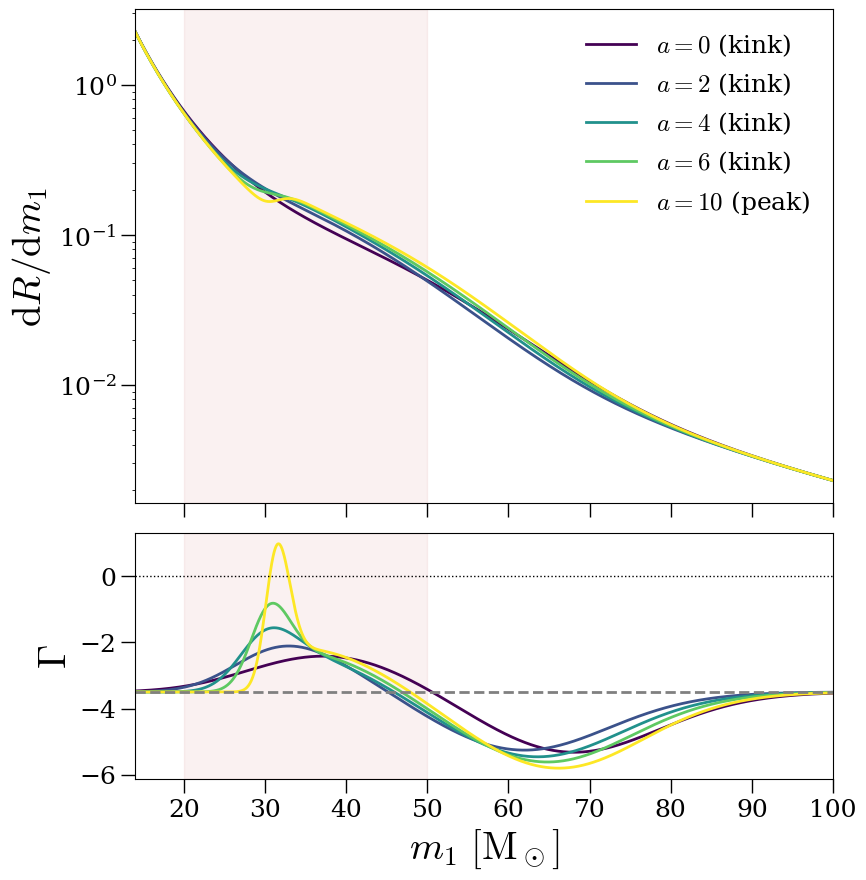

In [42]:
skew_values = [0.0, 2.0, 4.0, 6.0, 10.0]
colors = [cmap(i / max(len(skew_values) - 1, 1)) for i in range(len(skew_values))]

fig, (ax, axs) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                              gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))
for a in (ax, axs):
    a.axvspan(20, 50, color=C_G, alpha=0.08, zorder=0)

for a_val, c in zip(skew_values, colors):
    mdl = replace(model, skew=a_val)
    mono = 'kink' if mdl.is_monotonic() else 'peak'
    ax.semilogy(m, mdl.dRdm(m), color=c, label=rf'$a={a_val:.0f}$ ({mono})')
    axs.plot(m, mdl.log_slope(m), color=c)

axs.axhline(-model.alpha, ls='--', color='0.5')
axs.axhline(0.0, ls=':', color='k', lw=1)
ax.set_ylabel(r'$\mathrm{d}R/\mathrm{d}m_1$')
ax.legend(frameon=False, fontsize=18)
axs.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
axs.set_ylabel(r'$\Gamma$')
axs.set_xlim(m.min(), m.max())

savefig(fig, 'vary_skew')

## 6. Kink or peak?

The total stays a *slope change* rather than a *peak* as long as it never turns over,
$\Gamma(m) < 0$ everywhere. Rearranging the identity of Section 3 gives an **exact**,
shape-agnostic condition: writing $S(m) \equiv m\,\mathrm{d}\ln p_\mathrm{g}/\mathrm{d}m$
for the bump's steepening capacity,

$$\frac{g(m)}{1-g(m)}\;\frac{S(m)}{\alpha} \;<\; 1
\qquad\text{for all } m > m_\mathrm{min}+\delta_m .$$

$S>0$ only below the mode, so only the rising flank can threaten monotonicity. The
left-hand side is the **margin**; where it is maximised is the **binding mass**.

For a symmetric Gaussian $S = m(\mu-m)/\sigma^2$ and one can push this through to a closed
form, but that route does not survive the skew normal — and it was never more than a rough
guide anyway. Since the margin is exact and costs one grid evaluation, the notebook uses it
directly instead. `critical_f` then brackets the largest admissible $f$ by bisection,
which works for any shape.

The skew matters here in a way worth flagging: pinning the mode at $\mu$ and raising $a$
**steepens the rising flank**, which raises $S$ exactly where $g$ is already climbing. A
strongly skewed bump therefore turns into a visible peak at a considerably *smaller* $f$
than a symmetric one of the same scale.

In [43]:
def f_for_bump_fraction(model, g_target, m_eval):
    """Mixing fraction f giving a local bump fraction g_target at mass m_eval."""
    me = np.array([float(m_eval)])
    p_pl = model.pdf_pl(me)[0]
    p_g = model.pdf_g(me)[0]
    return g_target * p_pl / (p_g * (1.0 - g_target) + g_target * p_pl)


def monotonicity_margin(model):
    """(margin, binding mass) for the exact kink/peak condition of Section 6.

    margin < 1 -> dR/dm is monotonic (slope change only); margin > 1 -> a true peak.
    Equivalent to is_monotonic(), but it also says *where* the model is closest to
    turning over and by how much.
    """
    m = model.grid
    ok = (m >= model.m_min + model.delta_m) & (m < model.mu)
    m = m[ok]
    s = m * model.dln_pdf_g_dm(m)
    g = model.bump_fraction(m)
    margin = np.where(s > 0, g / np.maximum(1.0 - g, 1e-300) * s / model.alpha, 0.0)
    i = int(np.argmax(margin))
    return float(margin[i]), float(m[i])


def critical_f(model, f_hi=0.95, tol=1e-4, max_iter=80):
    """Largest f for which dR/dm stays monotonic. NaN if it never turns over."""
    if replace(model, f=f_hi).is_monotonic():
        return np.nan
    lo, hi = 0.0, f_hi
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        if replace(model, f=mid).is_monotonic():
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)

In [44]:
fid = replace(model, n_grid=1500)
margin, m_bind = monotonicity_margin(fid)

print(f'binding mass        = {m_bind:.1f} Msun')
print(f'margin              = {margin:.3f}   (< 1 -> kink only)')
print(f'is_monotonic()      = {fid.is_monotonic()}')
print(f'exact f_crit        = {critical_f(fid):.4f}')
print()
print('  skew   f_crit   m_bind')
for a_val in (0.0, 2.0, 4.0, 6.0, 10.0):
    mdl = replace(fid, skew=a_val)
    print(f'{a_val:6.1f}{critical_f(mdl):9.4f}{monotonicity_margin(replace(mdl, f=critical_f(mdl)))[1]:9.1f}')

binding mass        = 30.8 Msun
margin              = 0.690   (< 1 -> kink only)
is_monotonic()      = True
exact f_crit        = 0.0984

  skew   f_crit   m_bind
   0.0   0.6224     29.4
   2.0   0.3149     29.8
   4.0   0.1591     30.2
   6.0   0.0984     30.8
  10.0   0.0520     31.7


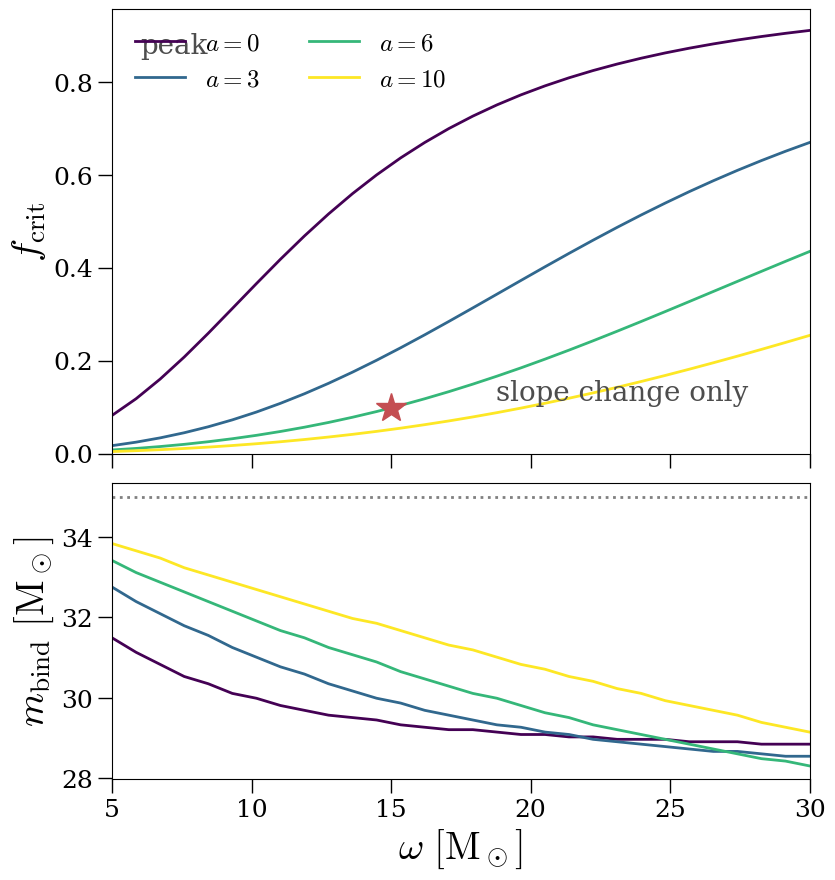

In [45]:
omegas = np.linspace(5.0, 30.0, 30)
skews = [0.0, 3.0, 6.0, 10.0]
colors = [cmap(i / max(len(skews) - 1, 1)) for i in range(len(skews))]

fig, (ax, axb) = plt.subplots(2, 1, figsize=(9, 10), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 2], hspace=0.08))

for a_val, c in zip(skews, colors):
    base = replace(model, skew=a_val, n_grid=1500)
    fc, mb = [], []
    for w in omegas:
        mdl = replace(base, omega=w)
        fcw = critical_f(mdl)
        fc.append(fcw)
        mb.append(monotonicity_margin(replace(mdl, f=fcw))[1] if fcw == fcw else np.nan)
    ax.plot(omegas, fc, color=c, label=rf'$a={a_val:.0f}$')
    axb.plot(omegas, mb, color=c)

ax.plot(model.omega, critical_f(replace(model, n_grid=1500)), '*', ms=22, color=C_G, zorder=5)
ax.set_ylabel(r'$f_\mathrm{crit}$')
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=18, ncol=2)
ax.text(0.04, 0.90, 'peak', transform=ax.transAxes, fontsize=20, color='0.3')
ax.text(0.55, 0.12, 'slope change only', transform=ax.transAxes, fontsize=20, color='0.3')

axb.axhline(model.mu, ls=':', color='0.5')
axb.set_xlabel(r'$\omega\ [\mathrm{M}_\odot]$')
axb.set_ylabel(r'$m_\mathrm{bind}\ [\mathrm{M}_\odot]$')
axb.set_xlim(omegas.min(), omegas.max())

savefig(fig, 'kink_vs_peak_threshold')

Below each curve the second population only bends the slope; above it, the total develops
a genuine local maximum. Two things stand out:

- **Skew costs budget.** At fixed $\omega$, raising $a$ from $0$ to $10$ lowers
  $f_\mathrm{crit}$ substantially. Pinning the mode and steepening the rising flank raises
  $S$ precisely where $g$ is climbing, so a lopsided bump betrays itself at a smaller
  branching fraction than a symmetric one of the same scale.
- **The binding mass sits below the mode** and moves down as $\omega$ grows — the total is
  closest to turning over on the rising flank, not at the peak, which is why reading the
  local fraction $g$ at $\mu$ is the wrong diagnostic.

**A caveat worth stating explicitly.** A shallow skewed bump and a broken power law with a
slope change in the same place are nearly indistinguishable from $\mathrm{d}R/\mathrm{d}m$
alone — set `alpha_low` and `m_break` to convince yourself. Arguing for two populations
needs something the single-population model cannot do: another dimension (spin, redshift),
or a feature sharp enough that the required $\alpha_2$ becomes implausible.

## 7. Interactive explorer

Sliders over the same model. If `ipywidgets` is unavailable, build a `ToyMassModel(...)`
by hand and re-run the Section 2 cells instead.

In [46]:
try:
    from ipywidgets import interact, FloatSlider
    _HAS_WIDGETS = True
except ImportError:
    _HAS_WIDGETS = False
    print('ipywidgets unavailable - edit ToyMassModel(...) by hand instead.')


def _explore(alpha=3.5, m_min=10.0, delta_m=4.0, mu=35.0, omega=15.0, skew=6.0, f=0.07):
    mdl = ToyMassModel(alpha=alpha, m_min=m_min, delta_m=delta_m, mu=mu,
                       omega=omega, skew=skew, f=f, n_grid=1500)
    mm = np.linspace(mdl.m_min + mdl.delta_m, mdl.m_max, 900)
    pl_, gs_ = mdl.components(mm)
    tot_ = pl_ + gs_

    fig, (a0, a1) = plt.subplots(2, 1, figsize=(9, 9), sharex=True,
                                 gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))
    for a in (a0, a1):
        a.axvspan(20, 50, color=C_G, alpha=0.08, zorder=0)
    a0.semilogy(mm, pl_, ls='--', color=C_PL)
    a0.semilogy(mm, gs_, ls=':', color=C_G)
    a0.semilogy(mm, tot_, color=C_TOT)
    a0.set_ylim(tot_.min() * 0.4, tot_.max() * 2.5)
    a0.set_ylabel(r'$\mathrm{d}R/\mathrm{d}m_1$')

    margin, m_bind = monotonicity_margin(mdl)
    verdict = 'slope change only' if mdl.is_monotonic() else 'true peak'
    a0.set_title(rf'{verdict}: margin$\,={margin:.2f}$ at ${m_bind:.0f}\,$M$_\odot$',
                 fontsize=20)

    a1.plot(mm, mdl.log_slope(mm), color=C_TOT)
    a1.axvline(m_bind, ls='-.', color='0.6', lw=1.5)
    a1.axhline(-alpha, ls='--', color=C_PL)
    a1.axhline(0.0, ls=':', color='k', lw=1)
    a1.set_xlabel(r'$m_1\ [\mathrm{M}_\odot]$')
    a1.set_ylabel(r'$\Gamma$')
    a1.set_xlim(mm.min(), mm.max())
    plt.show()


if _HAS_WIDGETS:
    interact(_explore,
             alpha=FloatSlider(min=1.0, max=6.0, step=0.1, value=3.5,
                               description=r'$\alpha$'),
             m_min=FloatSlider(min=5.0, max=20.0, step=0.5, value=10.0,
                               description=r'$m_\mathrm{min}$'),
             delta_m=FloatSlider(min=0.0, max=10.0, step=0.5, value=4.0,
                                 description=r'$\delta_m$'),
             mu=FloatSlider(min=20.0, max=60.0, step=0.5, value=35.0,
                            description=r'$\mu$ (mode)'),
             omega=FloatSlider(min=3.0, max=35.0, step=0.5, value=15.0,
                               description=r'$\omega$'),
             skew=FloatSlider(min=0.0, max=15.0, step=0.25, value=6.0,
                              description=r'$a$ (skew)'),
             f=FloatSlider(min=0.0, max=0.6, step=0.005, value=0.07,
                           description=r'$f$'))

interactive(children=(FloatSlider(value=3.5, description='$\\alpha$', max=6.0, min=1.0), FloatSlider(value=10.…